In [10]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from skimage.feature import hog

In [2]:
def load_images_hist(directory, target_size=(128, 128), color_mode='grayscale'):
    """
    Load images from a directory with improved error handling and flexibility.
    
    Args:
        directory (str): Path to the main directory containing class subdirectories
        target_size (tuple): Desired image resize dimensions
        color_mode (str): Color mode for image loading ('grayscale' or 'color')
    
    Returns:
        tuple: Features and labels arrays
    """
    # Define class mapping dynamically based on subdirectories
    class_mapping = {}
    
    data = []
    labels = []
    
    # Dynamically map subdirectories to class labels
    for i, subdir in enumerate(sorted(os.listdir(directory))):
        subdir_path = os.path.join(directory, subdir)
        
        if os.path.isdir(subdir_path):
            if(subdir == 'cats'):
                continue
            class_mapping[subdir] = i
            
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)
                
                if os.path.isfile(filepath):
                    # Load image based on color mode
                    if color_mode == 'grayscale':
                        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    else:
                        image = cv2.imread(filepath)
                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    
                    # Resize image
                    image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
                    
                    # Compute histogram features
                    if color_mode == 'grayscale':
                        hist = cv2.calcHist([image], [0], None, [128], [0, 256])
                    else:
                        # Color histogram for RGB images
                        hist_r = cv2.calcHist([image], [0], None, [64], [0, 256])
                        hist_g = cv2.calcHist([image], [1], None, [64], [0, 256])
                        hist_b = cv2.calcHist([image], [2], None, [64], [0, 256])
                        hist = np.concatenate([hist_r, hist_g, hist_b]).flatten()
                    
                    hist_normalized = hist / hist.sum()
                    data.append(hist_normalized.flatten())
                    
                    # Assign label
                    labels.append(class_mapping[subdir])
    
    print("Class Mapping:", class_mapping)
    return np.array(data), np.array(labels), class_mapping

In [3]:
def load_images_gabor(directory, target_size=(128, 128), color_mode='grayscale'):
    """
    Load images from a directory with improved error handling and flexibility.
    
    Args:
        directory (str): Path to the main directory containing class subdirectories
        target_size (tuple): Desired image resize dimensions
        color_mode (str): Color mode for image loading ('grayscale' or 'color')
    
    Returns:
        tuple: Features and labels arrays
    """
    # Define class mapping dynamically based on subdirectories
    class_mapping = {}
    
    data = []
    labels = []
    # Gabor filter parameters
    ksize = 5  # Kernel size
    sigma = 1.0
    lambd = 10.0
    gamma = 0.5
    thetas = [0, 45, 90, 135]  # Orientations in degrees

    # Dynamically map subdirectories to class labels
    for i, subdir in enumerate(sorted(os.listdir(directory))):
        subdir_path = os.path.join(directory, subdir)
        
        if os.path.isdir(subdir_path):
            if(subdir == 'cats'):
                continue
            class_mapping[subdir] = i
            
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)
                
                if os.path.isfile(filepath):
                    # Load image based on color mode
                    if color_mode == 'grayscale':
                        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    else:
                        image = cv2.imread(filepath)
                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    
                    # Resize image
                    image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
                    
                    gabor_features = []
                    for theta in thetas:
                        theta_rad = np.deg2rad(theta)
                        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta_rad, lambd, gamma, 0, ktype=cv2.CV_32F)
                        filtered_img = cv2.filter2D(image, cv2.CV_8UC3, kernel)  # Apply Gabor filter

                        gabor_features.append(np.mean(filtered_img))  # Mean response
                        gabor_features.append(np.var(filtered_img))   # Variance response

                    data.append(gabor_features)
                    
                    # Assign label
                    labels.append(class_mapping[subdir])
    
    print("Class Mapping:", class_mapping)
    return np.array(data), np.array(labels), class_mapping

In [11]:
def load_images_hog(directory, target_size=(128, 128), color_mode='grayscale'):
    """
    Load images from a directory with improved error handling and flexibility.
    
    Args:
        directory (str): Path to the main directory containing class subdirectories
        target_size (tuple): Desired image resize dimensions
        color_mode (str): Color mode for image loading ('grayscale' or 'color')
    
    Returns:
        tuple: Features and labels arrays
    """
    # Define class mapping dynamically based on subdirectories
    class_mapping = {}
    
    data = []
    labels = []

    # Dynamically map subdirectories to class labels
    for i, subdir in enumerate(sorted(os.listdir(directory))):
        subdir_path = os.path.join(directory, subdir)
        
        if os.path.isdir(subdir_path):
            if(subdir == 'cats'):
                continue
            class_mapping[subdir] = i
            
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)
                
                if os.path.isfile(filepath):
                    # Load image based on color mode
                    if color_mode == 'grayscale':
                        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
                    else:
                        image = cv2.imread(filepath)
                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    
                    # Resize image
                    image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
                    
                    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
                                       cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)

                    data.append(hog_features)
                    
                    # Assign label
                    labels.append(class_mapping[subdir])
    
    print("Class Mapping:", class_mapping)
    return np.array(data), np.array(labels), class_mapping

In [5]:
def train_decision_tree_classifier(X_train, y_train, X_test, y_test, n_iterations=100):
    """
    Train decision tree classifiers with different configurations.
    
    Args:
        X_train, y_train: Training data and labels
        X_test, y_test: Test data and labels
        n_iterations: Number of iterations for random state variation
    
    Returns:
        tuple: Best accuracy, best model, and detailed results
    """
    results = {
        'entropy': {'accuracies': [], 'best_model': None, 'best_accuracy': 0},
        'gini': {'accuracies': [], 'best_model': None, 'best_accuracy': 0}
    }
    
    for criterion in ['entropy', 'gini']:
        for random_state in range(1, n_iterations + 1):
            clf = DecisionTreeClassifier(
                criterion=criterion, 
                random_state=random_state,
            )
            
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred) * 100
            
            results[criterion]['accuracies'].append(accuracy)
            
            if accuracy > results[criterion]['best_accuracy']:
                results[criterion]['best_accuracy'] = accuracy
                results[criterion]['best_model'] = clf
    
    return results

In [6]:
def visualize_results(y_true, y_pred, class_names):
    """
    Visualize classification results and generate performance metrics.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
    """
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

Class Mapping: {'butterfly': 0, 'dogs': 2}
Class Mapping: {'butterfly': 0, 'dogs': 2}

Entropy Criterion Results:
Best Accuracy: 70.00%
Mean Accuracy: 65.84%
Accuracy Std Dev: 1.84%

Gini Criterion Results:
Best Accuracy: 70.00%
Mean Accuracy: 64.92%
Accuracy Std Dev: 1.96%

Classification Report:
              precision    recall  f1-score   support

   butterfly       0.76      0.69      0.72        90
        dogs       0.64      0.71      0.68        70

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.71      0.70      0.70       160



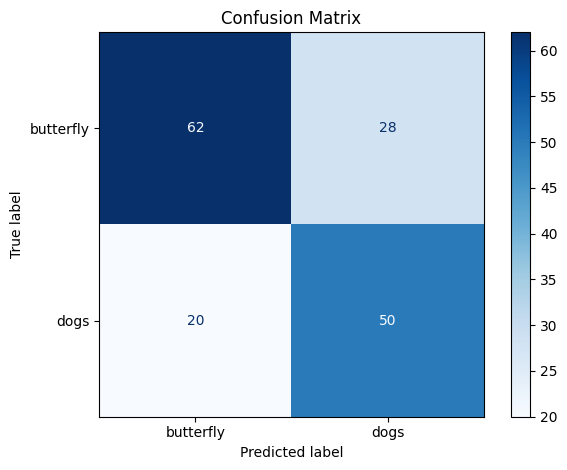

In [12]:
def main():
    # Paths to training and testing datasets
    train_directory = r"C:\D folder\Programming\programs\my codes\ML codes\knn classifier\Dog-Cat Dataset\train"
    test_directory = r"C:\D folder\Programming\programs\my codes\ML codes\knn classifier\Dog-Cat Dataset\test"
    
    # Load features and labels
    features_train, labels_train, class_mapping = load_images_hog(train_directory)
    features_test, labels_test, _ = load_images_hog(test_directory)
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(features_train)
    X_test_scaled = scaler.transform(features_test)
    
    # Train and evaluate classifiers
    results = train_decision_tree_classifier(
        X_train_scaled, labels_train, 
        X_test_scaled, labels_test
    )
    
    # Print results
    for criterion, data in results.items():
        print(f"\n{criterion.capitalize()} Criterion Results:")
        print(f"Best Accuracy: {data['best_accuracy']:.2f}%")
        print(f"Mean Accuracy: {np.mean(data['accuracies']):.2f}%")
        print(f"Accuracy Std Dev: {np.std(data['accuracies']):.2f}%")
    
    # Visualize results with the best model (using entropy criterion)
    best_entropy_model = results['entropy']['best_model']
    y_pred = best_entropy_model.predict(X_test_scaled)
    
    # Get class names in order
    class_names = [key for key, value in sorted(class_mapping.items(), key=lambda x: x[1])]
    visualize_results(labels_test, y_pred, class_names)

if __name__ == "__main__":
    main()